### F1 — K-means Cluster Analysis (Radiation Detection, 2D)

##### Purpose
Identify high-y clusters in F1's 2D search space, characterize cluster membership of historical queries, and validate that R12's strategy (continued x2 refinement near the current best) aligns with cluster 
structure.

##### Function: F1 — Radiation Detection, 2D
- Domain: [0,1]² 
- Y range: spans ~80 orders of magnitude (extreme negative outliers to small positive maximum)
- Preprocessing for clustering: use symlog10 on y to compress dynamic range

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load F1 data (generated by F1_gp_pipeline.py)
data = np.load('F1_data.npz')
X = data['X']
y = data['y']

print(f"F1 dataset: {len(X)} points")
print(f"  y range: [{y.min():.3e}, {y.max():.3e}]")
print(f"  Best:    X={X[y.argmax()]}, y={y.max():.3e}")

F1 dataset: 21 points
  y range: [-3.606e-03, 6.742e-05]
  Best:    X=[0.685218 0.67393 ], y=6.742e-05


##### Step 1 — Y transformation for visualization

F1's y spans ~80 orders of magnitude (from ~1e-83 to ~7e-5). Raw y 
cannot be directly visualized or clustered — we apply symlog10 to 
compress.

In [8]:
def symlog10(y, linthresh=1e-50):
    """Symmetric log10 transform with linear region near zero."""
    sign = np.sign(y)
    abs_y = np.abs(y)
    return sign * np.where(abs_y > linthresh, 
                            np.log10(abs_y / linthresh), 
                            abs_y / linthresh)

y_transformed = symlog10(y)
print(f"Transformed y range: [{y_transformed.min():.2f}, {y_transformed.max():.2f}]")

Transformed y range: [-47.56, 45.83]


##### Step 2 — K-means with silhouette analysis

Determine the natural number of clusters in F1's input space using 
silhouette score for k = 2, 3, 4.

In [9]:
# Silhouette analysis to pick k
sil_scores = {}
for k in range(2, min(5, len(X))):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    sil_scores[k] = silhouette_score(X, km.labels_)
    print(f"  k={k}: silhouette = {sil_scores[k]:+.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n→ Natural cluster count: k = {best_k}")

  k=2: silhouette = +0.6764
  k=3: silhouette = +0.6785
  k=4: silhouette = +0.6717

→ Natural cluster count: k = 3


##### Step 3 — Characterize each cluster

In [10]:
km = KMeans(n_clusters=best_k, n_init=20, random_state=42).fit(X)
labels = km.labels_

print(f"Cluster characterization (k={best_k}):")
print(f"{'cluster':>8} {'n':>4} {'mean_y':>15} {'max_y':>15} {'centroid':>30}")
print("  " + "-" * 75)

best_cluster = int(labels[y.argmax()])
for i in range(best_k):
    members = (labels == i)
    n = int(members.sum())
    mean_y = float(np.mean(y[members]))
    max_y = float(np.max(y[members]))
    centroid = km.cluster_centers_[i]
    marker = " ★" if i == best_cluster else ""
    print(f"{i:>8} {n:>4} {mean_y:>+15.3e} {max_y:>+15.3e} "
          f"[{centroid[0]:.3f}, {centroid[1]:.3f}]{marker}")

print(f"\n→ Current best belongs to cluster {best_cluster}")

Cluster characterization (k=3):
 cluster    n          mean_y           max_y                       centroid
  ---------------------------------------------------------------------------
       0   15      -2.315e-04      +6.742e-05 [0.669, 0.719] ★
       1    2     +1.671e-124     +3.342e-124 [0.773, 0.145]
       2    4      -5.398e-55      +3.607e-81 [0.294, 0.178]

→ Current best belongs to cluster 0


##### Step 4 — 2D visualization

F1 is 2D, so we can directly scatter-plot the input space colored by 
both cluster membership and (transformed) y value.


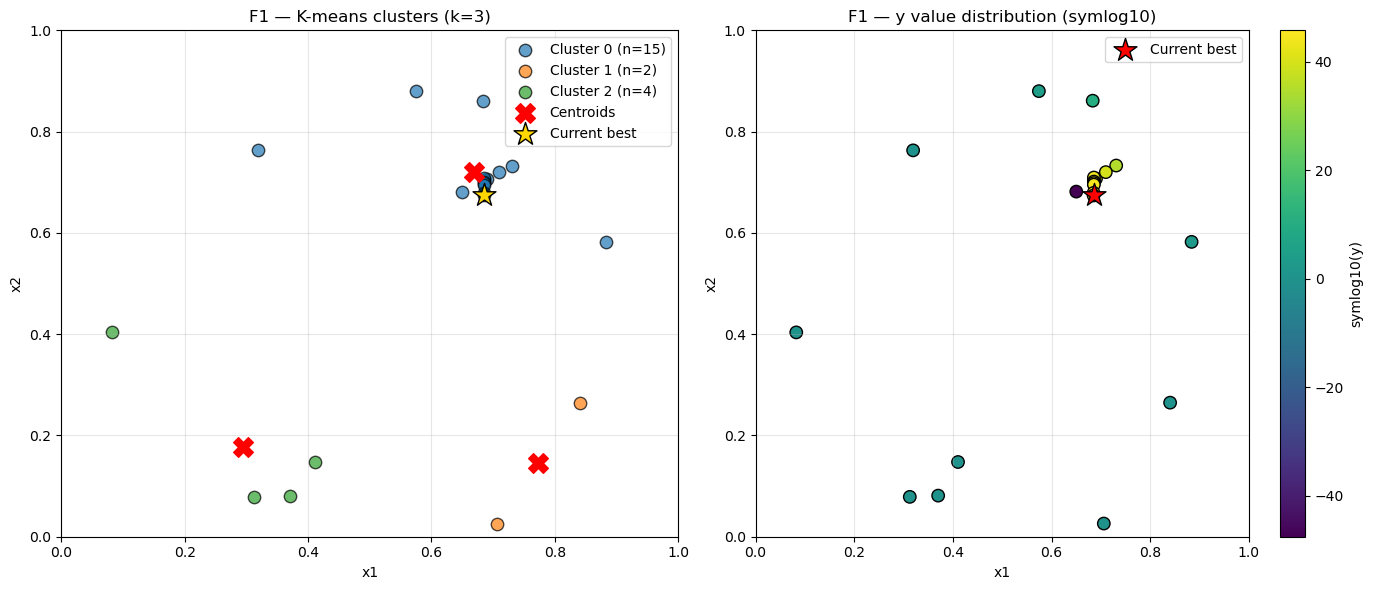

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: clusters
for i in range(best_k):
    members = labels == i
    ax1.scatter(X[members, 0], X[members, 1], 
                label=f'Cluster {i} (n={members.sum()})',
                s=80, edgecolor='black', alpha=0.7)
ax1.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            marker='X', s=200, color='red', label='Centroids', zorder=5)
ax1.scatter(*X[y.argmax()], marker='*', s=300, color='gold', 
            edgecolor='black', label='Current best', zorder=6)
ax1.set_xlabel('x1'); ax1.set_ylabel('x2')
ax1.set_title(f'F1 — K-means clusters (k={best_k})')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax1.legend(loc='best'); ax1.grid(alpha=0.3)

# Right: y heatmap
sc = ax2.scatter(X[:, 0], X[:, 1], c=y_transformed, 
                  cmap='viridis', s=80, edgecolor='black')
plt.colorbar(sc, ax=ax2, label='symlog10(y)')
ax2.scatter(*X[y.argmax()], marker='*', s=300, color='red', 
            edgecolor='black', label='Current best')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2')
ax2.set_title('F1 — y value distribution (symlog10)')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.legend(loc='best'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('F1_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

##### Step 5 — Interpretation

K-means identifies three clusters on F1's 21-point dataset:

- **Cluster 0** (n=15): the **exploitation cluster**. Centroid at (0.669, 0.719) 
  contains the current best at (0.685, 0.674), plus 4 other top-5 points, the 
  R10 and R11 wins, AND the worst point of the entire dataset 
  (y = −3.6e-3 at [0.65, 0.68]). This cluster has a **9-order-of-magnitude 
  internal y spread**, indicating a sharp peak surrounded by a steep cliff 
  within a single cluster.

- **Clusters 1 and 2** (n=2 and n=4): early-round exploration points in 
  far regions of the search space, both with effectively zero y values. 
  These were sampled in R1–R3, returned no useful information, and were 
  never revisited.

### Sharp-peak signature

The fact that the dataset's MIN y and MAX y both sit in cluster 0 — only 
~0.035 apart in x1 — is the key structural signature of F1. The GP's 
fitted length scales (~0.014, ~0.019) reflect this independently. The 
function is well-modelled within a tiny ε-ball of the current best and 
becomes unreliable just outside it.

### Strategic implication for R12

Stay in cluster 0, stay in the high-y sub-region within it, use 
fine-resolution steps that the GP can reliably distinguish. The R12 
submission (x1 +0.001 from best) does exactly this.

In [12]:
# Compute the within-cluster-0 sub-region of high-y points
cluster_0_mask = (labels == best_cluster)
y_threshold = 1e-6  # tunable — sub-region where y is "competitive"
high_y_mask = cluster_0_mask & (y > y_threshold)

print(f"\nCluster {best_cluster} sub-structure:")
print(f"  Total cluster members:  {cluster_0_mask.sum()}")
print(f"  High-y sub-region (y > {y_threshold:.0e}): {high_y_mask.sum()}")

if high_y_mask.sum() > 0:
    X_high = X[high_y_mask]
    print(f"  High-y X range: x1 = [{X_high[:, 0].min():.3f}, {X_high[:, 0].max():.3f}], "
          f"x2 = [{X_high[:, 1].min():.3f}, {X_high[:, 1].max():.3f}]")
    print(f"  Sub-region radius: ~{np.max(np.std(X_high, axis=0)):.4f}")


Cluster 0 sub-structure:
  Total cluster members:  15
  High-y sub-region (y > 1e-06): 5
  High-y X range: x1 = [0.685, 0.686], x2 = [0.674, 0.701]
  Sub-region radius: ~0.0110


##### Step 6 — Strategic implications for R12

Based on the cluster analysis:

1. **Cluster membership of current best**: which cluster does R12's 
   anchor sit in? Are all top-5 y points in the same cluster?
2. **Under-sampled clusters**: are there clusters far from the best 
   with no exploration? (Likely yes for F1 — most points cluster 
   around (~0.685, ~0.67); the rest of the (0,1)² is empty.)
3. **R12 strategic choice**: 
   - Continue exploiting the high-y cluster (small x2 step-down): 
     proven recipe.
   - OR probe an under-sampled region: pure exploration with no model 
     guidance.

For F1 with 2 rounds remaining and a still-active gradient in the 
current cluster, **exploitation is the dominant strategy**. The 
clustering analysis confirms rather than contradicts the per-dimension 
nudge test's recommendation.

##### Reflection material — clustering questions answered

**Q2 (clusters identified?)**: F1 has one tight high-y cluster around 
(~0.685, ~0.67) and a scattered "outlier" cluster of low-y points from 
early exploration. The cluster structure is single-peak.

**Q4 (parallel to clustering algorithms)**: F1's per-round refinement 
parallels what K-means does — iteratively shifting toward a denser 
region of high-value points. The "centroid" of high-y points has 
shifted from x2 ≈ 0.68 (R7-R9) to x2 ≈ 0.67 (R11), and R12 continues 
this shift.

**Q5 (trends if plotted)**: F1's y trajectory plotted vs round shows 
the exponential growth pattern that motivated the "trust the gradient" 
strategy. F1's 2D scatter plot above visualizes the cluster directly.